In [12]:
from pathlib import Path

import uproot

DATA_FILENAME = "JetNtuple_RunIISummer16_13TeV_MC_1.root"
SEARCH_ROOTS = (Path.cwd(), Path.cwd().parent)
candidate_paths = [
    base / relative_path
    for base in SEARCH_ROOTS
    for relative_path in (
        Path("data") / "raw" / DATA_FILENAME,
        Path("QCDJetsMachineLearning") / DATA_FILENAME,
    )
]
ROOT_PATH = next((path for path in candidate_paths if path.is_file()), None)
if ROOT_PATH is None:
    raise FileNotFoundError(f"Could not find {DATA_FILENAME} from {Path.cwd()}")
ROOT_PATH = ROOT_PATH.resolve()
print(f"Data file: {ROOT_PATH}")

f = uproot.open(ROOT_PATH)
classnames = f.classnames(recursive=True)   # {name: ROOT classname} — digs into every subdirectory, not just the top level

# takes objects of a certain type (Tree or RNTuple)
tree_candidates = [k for k, cls in classnames.items() if "Tree" in cls or "RNTuple" in cls]

# function to extract the cycle number (version)
def cycle_num(key):
    return int(key.rsplit(";", 1)[1]) if ";" in key else 0

# the goal is to take the highest cycle (newest version)
tree_candidates.sort(key=cycle_num, reverse=True)   
tree = f[tree_candidates[0]]

print(f"Using: {tree_candidates[0]}")
#print(tree.keys())   # branch/features names

for key in tree.keys():
    print(key)

Data file: D:\OneDrive - The University of Manchester\summer2026\SCIML\jet praticales\data\raw\JetNtuple_RunIISummer16_13TeV_MC_1.root
Using: AK4jets/jetTree;3
jetPt
jetEta
jetPhi
jetMass
jetGirth
jetArea
jetRawPt
jetRawMass
jetLooseID
jetTightID
jetGenMatch
jetQGl
QG_ptD
QG_axis2
QG_mult
partonFlav
hadronFlav
physFlav
isPhysUDS
isPhysG
isPhysOther
isPartonUDS
isPartonG
isPartonOther
jetChargedHadronMult
jetNeutralHadronMult
jetChargedMult
jetNeutralMult
jetMult
nPF
PF_pT
PF_dR
PF_dTheta
PF_dPhi
PF_dEta
PF_mass
PF_id
PF_fromPV
PF_fromAK4Jet
genJetPt
genJetEta
genJetPhi
genJetMass
nGenJetPF
genJetPF_pT
genJetPF_dR
genJetPF_dTheta
genJetPF_mass
genJetPF_id
eventJetMult
jetPtOrder
dPhiJetsLO
dEtaJetsLO
alpha
event
run
lumi
pthat
eventWeight
rhoAll
rhoCentral
rhoCentralNeutral
rhoCentralChargedPileUp
PV_npvsGood
Pileup_nPU
Pileup_nTrueInt


In [13]:
import awkward as ak
import numpy as np
import torch
from torch_geometric.data import Data

K_NEIGHBORS = 8
particle_feature_names = ("log_pT", "dEta", "dPhi", "log_pT_over_jetPt")

branches = [
    "run",
    "lumi",
    "event",
    "physFlav",
    "isPhysUDS",
    "isPhysG",
    "jetPt",
    "PF_pT",
    "PF_dEta",
    "PF_dPhi",
    "PF_fromAK4Jet",
]
raw_data = tree.arrays(branches, library="ak")

# Keep only jets with exactly one of the two requested labels.
is_quark = raw_data["isPhysUDS"] == 1
is_gluon = raw_data["isPhysG"] == 1
selected_jets = raw_data[is_quark ^ is_gluon]


def build_knn_edges(pos, k=K_NEIGHBORS):
    """Build geometric k-NN edges for one jet (plotting only)."""
    num_nodes = pos.size(0)
    if num_nodes < 2:
        return torch.empty((2, 0), dtype=torch.long, device=pos.device)
    local_k = min(k, num_nodes - 1)
    distances = torch.cdist(pos, pos)
    distances.fill_diagonal_(float("inf"))
    neighbours = distances.topk(local_k, largest=False).indices
    target = torch.arange(num_nodes, device=pos.device).repeat_interleave(local_k)
    source = neighbours.reshape(-1)
    return torch.stack((source, target), dim=0)

# Store transformed but not yet standardised features. Standardisation happens
# after the event-safe split so validation/test information cannot leak into it.
jet_graphs = []
skipped_jets = 0
for jet in selected_jets:
    pf_pt_all = ak.to_numpy(jet["PF_pT"])
    constituent_mask = ak.to_numpy(jet["PF_fromAK4Jet"]) == 1
    constituent_mask &= np.isfinite(pf_pt_all) & (pf_pt_all > 0)
    jet_pt = float(jet["jetPt"])

    if constituent_mask.sum() < 2 or not np.isfinite(jet_pt) or jet_pt <= 0:
        skipped_jets += 1
        continue

    pf_pt = pf_pt_all[constituent_mask].astype(np.float32)
    d_eta = ak.to_numpy(jet["PF_dEta"])[constituent_mask].astype(np.float32)
    d_phi = ak.to_numpy(jet["PF_dPhi"])[constituent_mask].astype(np.float32)
    particle_matrix = np.column_stack(
        [np.log(pf_pt), d_eta, d_phi, np.log(pf_pt / jet_pt)]
    ).astype(np.float32)

    finite_rows = np.isfinite(particle_matrix).all(axis=1)
    particle_matrix = particle_matrix[finite_rows]
    pf_pt = pf_pt[finite_rows]
    if len(particle_matrix) < 2:
        skipped_jets += 1
        continue

    jet_graphs.append(
        Data(
            x=torch.from_numpy(particle_matrix),
            pos=torch.from_numpy(
                np.column_stack((d_eta, d_phi))[finite_rows].astype(np.float32)
            ),
            raw_pt=torch.from_numpy(pf_pt.copy()),
            y=torch.tensor([int(jet["isPhysG"])], dtype=torch.long),
            original_flavor=torch.tensor([int(jet["physFlav"])], dtype=torch.long),
            run=torch.tensor([int(jet["run"])], dtype=torch.long),
            lumi=torch.tensor([int(jet["lumi"])], dtype=torch.long),
            event=torch.tensor([int(jet["event"])], dtype=torch.long),
            event_id=torch.tensor([int(jet["event"])], dtype=torch.long),
        )
    )

print(f"PyG graphs created: {len(jet_graphs):,} / {len(raw_data):,} jets")
print(f"Skipped invalid/small selected jets: {skipped_jets:,}")
print("Node feature columns:", particle_feature_names)
print("Target convention: 0 = light quark (UDS), 1 = gluon")
print(jet_graphs[0])


PyG graphs created: 13,912 / 28,614 jets
Skipped invalid/small selected jets: 0
Node feature columns: ('log_pT', 'dEta', 'dPhi', 'log_pT_over_jetPt')
Target convention: 0 = light quark (UDS), 1 = gluon
Data(x=[26, 4], y=[1], pos=[26, 2], raw_pt=[26], original_flavor=[1], event_id=[1])


# Variables created in the previous cell

The first two lines import PyTorch and the PyG `Data` class. The main variables created by the cell are:

| Variable | Type or format | Content |
|---|---|---|
| `K_NEIGHBORS` | `int` | Number of nearest neighbours used for each particle (`8`). |
| `particle_feature_names` | `tuple[str, str, str]` | Names and order of the node features: `pT`, `dEta`, `dPhi`. |
| `branches` | `list[str]` | Names of the ROOT branches that are read. |
| `raw_data` | `awkward.Array` | All jets and the requested ROOT branches. |
| `is_quark` | `awkward.Array` of booleans | Selects light-quark jets. |
| `is_gluon` | `awkward.Array` of booleans | Selects gluon jets. |
| `selected_jets` | `awkward.Array` | Jets with one clear quark-or-gluon label. |
| `build_knn_edges` | function | Creates k-nearest-neighbour graph edges. |
| `jet_graphs` | `list[Data]` | Final list containing one PyG graph per jet. |

`raw_data` contains jet-level values such as `event` and `physFlav`, plus variable-length particle arrays such as `PF_pT`, `PF_dEta`, and `PF_dPhi`. Awkward Array is used because different jets contain different numbers of particles.

## Format of one jet graph

Each element of `jet_graphs` is a `torch_geometric.data.Data` object:

| Field | Type and shape | Content |
|---|---|---|
| `x` | `torch.FloatTensor [num_particles, 3]` | Particle rows in the order `[pT, dEta, dPhi]`. |
| `pos` | `torch.FloatTensor [num_particles, 2]` | Particle positions `[dEta, dPhi]`. |
| `edge_index` | `torch.LongTensor [2, num_edges]` | k-nearest-neighbour connections. |
| `y` | `torch.LongTensor [1]` | Jet target: `0` = light quark, `1` = gluon. |
| `original_flavor` | `torch.LongTensor [1]` | Original `physFlav` value kept as metadata. |
| `run`, `lumi`, `event` | `torch.LongTensor [1]` | Composite event identity used for the dataset split. |

Only particles with `PF_fromAK4Jet == 1` are included. `jet_graphs` is the complete filtered dataset and has not yet been split into training, validation, and test sets.

# Graph visualisation

This cell plots one example jet: particles are the points (size and colour scale
with pT), and the grey lines connect nearby particles.

**What these edges are - and are not:**

- The lines come from uild_knn_edges(graph.pos): a k-NN graph in the
  *geometric* space (dEta, dPhi) only. This is a **visualisation aid**.
- During training the model does **not** use these edges. DynamicEdgeConv
  recomputes the graph internally on *every* layer, in the *full* feature space
  [pT, dEta, dPhi] - so pT participates in the connectivity, and the graph
  structure changes as the features are learned.
- This plot therefore shows the jet as if neighbours were defined purely by
  geometry. Use it for data exploration and intuition; it is **not** an exact
  picture of the graph the model actually sees.


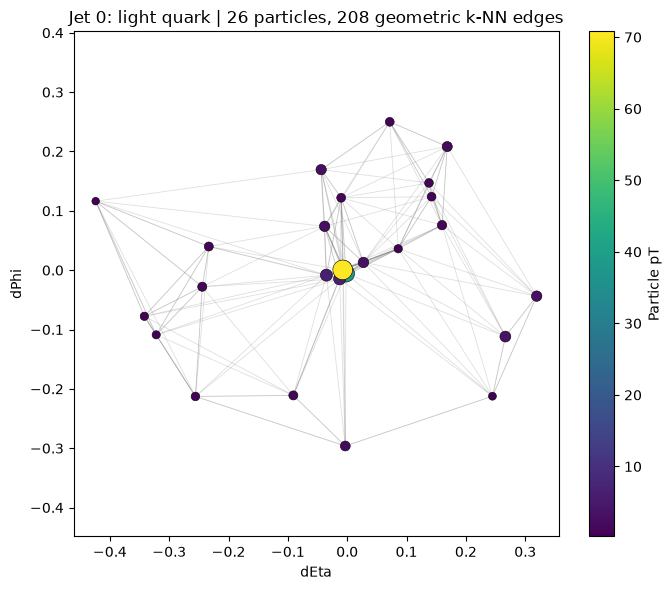

In [14]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection


def plot_graph(graph, graph_index=None, ax=None):
    """Plot one jet with geometric k-NN edges (visualisation only)."""
    graph = graph.cpu()
    positions = graph.pos.numpy()
    edge_index = build_knn_edges(graph.pos)
    edges = edge_index.numpy()
    particle_pt = graph.raw_pt.numpy()

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))
    else:
        fig = ax.figure

    segments = np.stack([positions[edges[0]], positions[edges[1]]], axis=1)
    ax.add_collection(
        LineCollection(segments, colors="gray", linewidths=0.6, alpha=0.25)
    )
    node_sizes = 20 + 180 * np.sqrt(particle_pt / particle_pt.max())
    nodes = ax.scatter(
        positions[:, 0],
        positions[:, 1],
        s=node_sizes,
        c=particle_pt,
        cmap="viridis",
        edgecolors="black",
        linewidths=0.4,
        zorder=2,
    )

    target_name = "gluon" if graph.y.item() == 1 else "light quark"
    jet_name = f"Jet {graph_index}" if graph_index is not None else "Jet"
    ax.set_title(
        f"{jet_name}: {target_name} | {graph.num_nodes} particles, "
        f"{edge_index.size(1)} geometric k-NN edges"
    )
    ax.set_xlabel("dEta")
    ax.set_ylabel("dPhi")
    ax.autoscale()
    ax.set_aspect("equal", adjustable="datalim")
    fig.colorbar(nodes, ax=ax, label="Particle pT")
    fig.tight_layout()
    return fig, ax


GRAPH_INDEX = 0
plot_graph(jet_graphs[GRAPH_INDEX], graph_index=GRAPH_INDEX)
plt.show()


# Check one graph

This cell prints one graph and its tensor shapes. It checks that the graph was created correctly.

In [15]:
g = jet_graphs[10]
dynamic_edge_index = build_knn_edges(g.pos)

print(g)
print(g.x.shape)
print(dynamic_edge_index.shape)
print(g.y)
print(g.original_flavor)

Data(x=[34, 4], y=[1], pos=[34, 2], raw_pt=[34], original_flavor=[1], event_id=[1])
torch.Size([34, 4])
torch.Size([2, 272])
tensor([1])
tensor([21])


# Dataset split

The next cells split the graphs into training, validation, and test sets. Jets from the same event stay in the same set.

In [16]:
import random

def event_identity(graph):
    return (int(graph.run.item()), int(graph.lumi.item()), int(graph.event.item()))


all_event_ids = sorted({event_identity(graph) for graph in jet_graphs})
random.Random(42).shuffle(all_event_ids)

num_events = len(all_event_ids)
num_train = int(num_events * 0.70)
num_validation = int(num_events * 0.15)
train_events = set(all_event_ids[:num_train])
validation_events = set(all_event_ids[num_train:num_train + num_validation])
test_events = set(all_event_ids[num_train + num_validation:])

train_graphs = [g for g in jet_graphs if event_identity(g) in train_events]
validation_graphs = [
    g for g in jet_graphs if event_identity(g) in validation_events
]
test_graphs = [g for g in jet_graphs if event_identity(g) in test_events]

# Fit feature scaling on training particles only, then reuse it unchanged.
train_particles = torch.cat([graph.x for graph in train_graphs], dim=0)
feature_mean = train_particles.mean(dim=0)
feature_std = train_particles.std(dim=0).clamp_min(1e-6)
for graph in jet_graphs:
    graph.x = (graph.x - feature_mean) / feature_std

train_targets = torch.cat([graph.y for graph in train_graphs])
num_train_gluons = int((train_targets == 1).sum())
num_train_quarks = int((train_targets == 0).sum())
pos_weight = num_train_quarks / max(num_train_gluons, 1)

print(f"Total jets: {len(jet_graphs):,}")
print(f"Train/validation/test: {len(train_graphs):,} / "
      f"{len(validation_graphs):,} / {len(test_graphs):,}")
print(f"Training quarks/gluons: {num_train_quarks:,} / {num_train_gluons:,}")
print("Training feature mean:", feature_mean)
print("Training feature std:", feature_std)


Total jets: 13,912
Train/validation/test: 9,736 / 2,084 / 2,092
Training quarks/gluons: 3,692 / 6,044
Training feature mean: tensor([ 8.7766e-01,  5.1389e-04,  1.3044e-04, -4.8508e+00])
Training feature std: tensor([1.4752, 0.1477, 0.1584, 1.5652])


In [17]:
assert train_events.isdisjoint(validation_events)
assert train_events.isdisjoint(test_events)
assert validation_events.isdisjoint(test_events)
assert len(train_graphs) + len(validation_graphs) + len(test_graphs) == len(jet_graphs)

print("Event-safe split passed.")

Event-safe split passed.


# Data loaders

This cell groups jet graphs into batches. The training loader shuffles the graphs.

In [18]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(
    train_graphs,
    batch_size=32,
    shuffle=True
)

validation_loader = DataLoader(
    validation_graphs,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_graphs,
    batch_size=32,
    shuffle=False
)

batch = next(iter(train_loader))

print(batch.x.shape)
#print(batch.edge_index.shape)
print(batch.y.shape)
print(batch.batch.shape)

torch.Size([1252, 4])
torch.Size([32])
torch.Size([1252])


# GNN model

This cell defines the neural network. It processes particles and produces one output for each jet.

In [19]:
from pathlib import Path
import sys

repository_root = next(
    path for path in (Path.cwd(), Path.cwd().parent)
    if (path / "jet_gnn.py").is_file()
)
if str(repository_root) not in sys.path:
    sys.path.insert(0, str(repository_root))

from jet_gnn import JetGNN

model = JetGNN(num_features=len(particle_feature_names), k=K_NEIGHBORS)
print(model)


JetGNN(
  (conv1): EdgeConv(nn=Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
  ))
  (conv2): EdgeConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  ))
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [20]:
import torch_geometric

print("PyTorch:", torch.__version__)
print("CUDA runtime:", torch.version.cuda)
print("PyG:", torch_geometric.__version__)
print("Dynamic graph backend: native torch.cdist + EdgeConv")


PyTorch: 2.13.0+cu130
CUDA runtime: 13.0
PyG: 2.8.0.post1
Dynamic graph backend: native torch.cdist + EdgeConv


# Check the model output

This cell runs one batch through the model. It checks that there is one logit for each jet.

In [21]:
# Check that the model returns one logit for every jet in the batch.
model.eval()
with torch.no_grad():
    logits = model(batch.x, batch.pos, batch.batch)

print("Input particles:", batch.x.shape)
print("Batch targets:", batch.y.shape)
print("Output logits:", logits.shape)
assert logits.shape == batch.y.shape

Input particles: torch.Size([1252, 4])
Batch targets: torch.Size([32])
Output logits: torch.Size([32])


# Model training

This cell trains the model and checks validation performance after each epoch. It then evaluates the test set.

In [22]:
# Train the binary jet classifier.
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = JetGNN(num_features=len(particle_feature_names)).to(device)
# Compute class weighting from this run's training subset, not hard-coded counts.
loss_function = torch.nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], device=device)
)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


def run_epoch(loader, training):
    model.train(training)
    total_loss = 0.0
    total_correct = 0
    total_jets = 0

    for batch in loader:
        batch = batch.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            logits = model(batch.x, batch.pos, batch.batch)
            targets = batch.y.float()
            loss = loss_function(logits, targets)

            if training:
                loss.backward()
                optimizer.step()

        predictions = (logits >= 0).long()
        total_loss += loss.item() * batch.num_graphs
        total_correct += (predictions == batch.y).sum().item()
        total_jets += batch.num_graphs

    return total_loss / total_jets, total_correct / total_jets


best_validation_loss = float("inf")
best_model_state = None
history = {
    "train_loss": [],
    "validation_loss": [],
    "train_accuracy": [],
    "validation_accuracy": [],
}

print(f"Training on: {device}")
for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_accuracy = run_epoch(train_loader, training=True)
    validation_loss, validation_accuracy = run_epoch(
        validation_loader, training=False
    )

    history["train_loss"].append(train_loss)
    history["validation_loss"].append(validation_loss)
    history["train_accuracy"].append(train_accuracy)
    history["validation_accuracy"].append(validation_accuracy)

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        best_model_state = {
            name: parameter.detach().cpu().clone()
            for name, parameter in model.state_dict().items()
        }

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_loss:.4f}, accuracy {train_accuracy:.3f} | "
        f"validation loss {validation_loss:.4f}, "
        f"accuracy {validation_accuracy:.3f}"
    )

# Restore the parameters from the epoch with the lowest validation loss.
model.load_state_dict(best_model_state)
test_loss, test_accuracy = run_epoch(test_loader, training=False)
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_accuracy:.3f}")

Training on: cuda


c:\Users\25533\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch 01 | train loss 0.4414, accuracy 0.690 | validation loss 0.4287, accuracy 0.743
Epoch 02 | train loss 0.4096, accuracy 0.740 | validation loss 0.4124, accuracy 0.749
Epoch 03 | train loss 0.4092, accuracy 0.742 | validation loss 0.4294, accuracy 0.749
Epoch 04 | train loss 0.4082, accuracy 0.734 | validation loss 0.4143, accuracy 0.719
Epoch 05 | train loss 0.4038, accuracy 0.744 | validation loss 0.4074, accuracy 0.739
Epoch 06 | train loss 0.3999, accuracy 0.740 | validation loss 0.4065, accuracy 0.748
Epoch 07 | train loss 0.3983, accuracy 0.744 | validation loss 0.4130, accuracy 0.763
Epoch 08 | train loss 0.3974, accuracy 0.748 | validation loss 0.4248, accuracy 0.699
Epoch 09 | train loss 0.3952, accuracy 0.748 | validation loss 0.4078, accuracy 0.761
Epoch 10 | train loss 0.3927, accuracy 0.752 | validation loss 0.4049, accuracy 0.747
Test loss: 0.3952 | Test accuracy: 0.748


# Training results

This cell plots training and validation loss and accuracy. It helps us see if the model is learning.

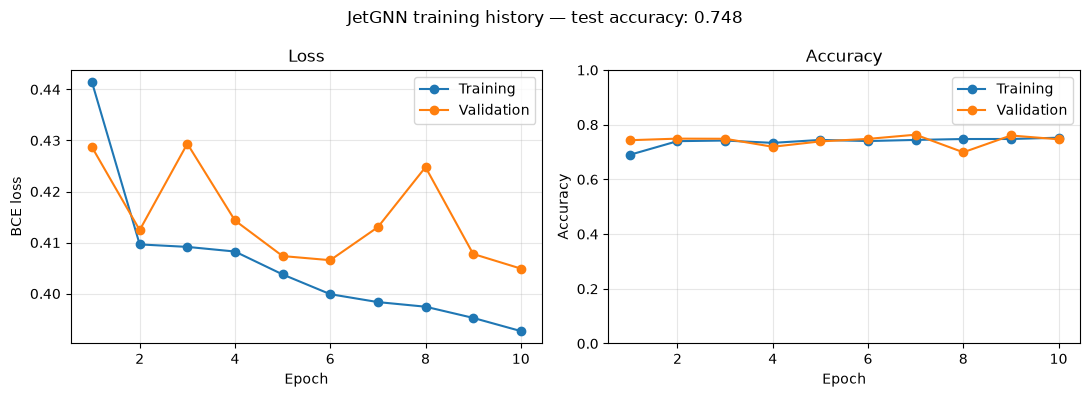

In [23]:
# Visualise the training and validation history.
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(epochs, history["train_loss"], marker="o", label="Training")
axes[0].plot(epochs, history["validation_loss"], marker="o", label="Validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, history["train_accuracy"], marker="o", label="Training")
axes[1].plot(epochs, history["validation_accuracy"], marker="o", label="Validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)
axes[1].legend()

fig.suptitle(f"JetGNN training history — test accuracy: {test_accuracy:.3f}")
fig.tight_layout()
plt.show()

Test ROC-AUC: 0.8207
Test balanced accuracy: 0.7401
Confusion matrix [[TN, FP], [FN, TP]]:
 [[ 558  228]
 [ 300 1006]]


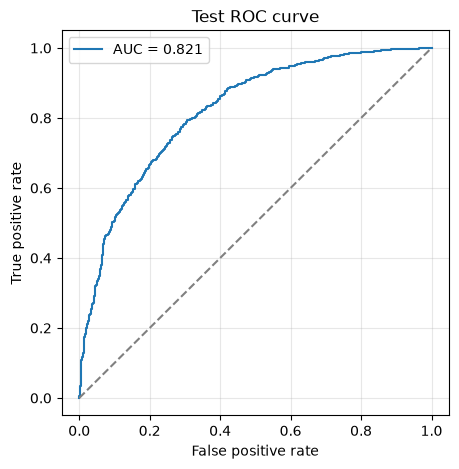

In [24]:
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)


def collect_predictions(loader):
    model.eval()
    logits_parts = []
    target_parts = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            logits_parts.append(model(batch.x, batch.pos, batch.batch).cpu())
            target_parts.append(batch.y.cpu())
    return torch.cat(logits_parts), torch.cat(target_parts)


test_logits, test_targets = collect_predictions(test_loader)
test_probabilities = torch.sigmoid(test_logits).numpy()
test_labels = test_targets.numpy()
test_predictions = (test_probabilities >= 0.5).astype(np.int64)

test_auc = roc_auc_score(test_labels, test_probabilities)
test_balanced_accuracy = balanced_accuracy_score(test_labels, test_predictions)
test_confusion_matrix = confusion_matrix(test_labels, test_predictions)
print(f"Test ROC-AUC: {test_auc:.4f}")
print(f"Test balanced accuracy: {test_balanced_accuracy:.4f}")
print("Confusion matrix [[TN, FP], [FN, TP]]:\n", test_confusion_matrix)

false_positive_rate, true_positive_rate, _ = roc_curve(
    test_labels, test_probabilities
)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(false_positive_rate, true_positive_rate, label=f"AUC = {test_auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set(xlabel="False positive rate", ylabel="True positive rate", title="Test ROC curve")
ax.legend()
ax.grid(alpha=0.3)
plt.show()
